In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os
os.listdir('/content/drive/MyDrive/Weather_project')

['weatherHistory.csv']

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
print(os.getcwd())

/content


In [8]:
df = pd.read_csv('/content/drive/MyDrive/Weather_project/weatherHistory.csv')
print("✅ Dataset loaded from Drive!")
df.head(2)

✅ Dataset loaded from Drive!


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.


In [3]:

from google.colab import files

# Upload your weatherHistory.csv file
uploaded = files.upload()

# Load the dataset
df = pd.read_csv('weatherHistory.csv')
print("✅ Dataset loaded!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

Saving weatherHistory.csv to weatherHistory.csv
✅ Dataset loaded!
Shape: 96453 rows × 12 columns


In [9]:
print("DATASET INFO:")
print(df.info())

print("\nMISSING VALUES:")
print(df.isnull().sum())

DATASET INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB
None

MISSING VALUES:
Formatted Date                0
S

In [10]:
print("📊 AVERAGE VALUES OF NUMERIC COLUMNS:")

numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    print(f"  Average {col}: {df[col].mean():.2f}")

📊 AVERAGE VALUES OF NUMERIC COLUMNS:
  Average Temperature (C): 11.93
  Average Apparent Temperature (C): 10.86
  Average Humidity: 0.73
  Average Wind Speed (km/h): 10.81
  Average Wind Bearing (degrees): 187.51
  Average Visibility (km): 10.35
  Average Loud Cover: 0.00
  Average Pressure (millibars): 1003.24


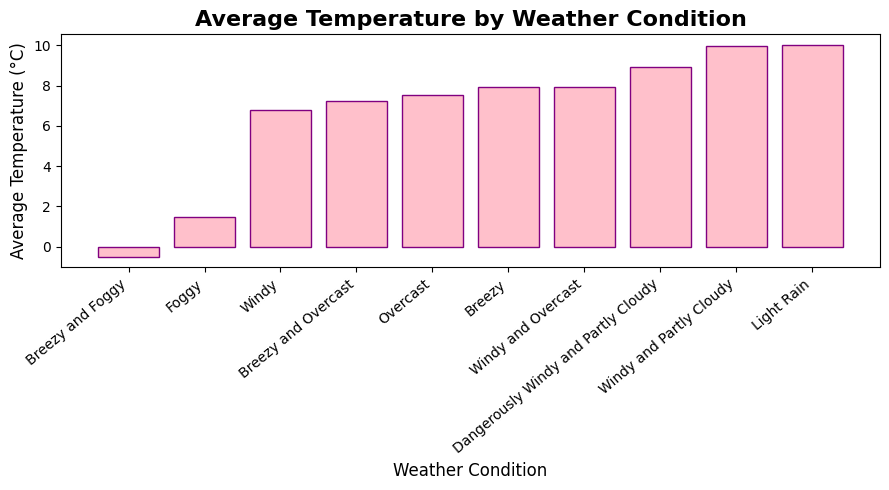

In [11]:
plt.figure(figsize=(9, 5))

# Average Temperature by Weather Summary
avg_temp = df.groupby('Summary')['Temperature (C)'].mean().sort_values(ascending=True).head(10)

plt.bar(avg_temp.index, avg_temp.values, color='pink', edgecolor='purple')
plt.title('Average Temperature by Weather Condition', fontsize=16, fontweight='bold')
plt.xlabel('Weather Condition', fontsize=12)
plt.ylabel('Average Temperature (°C)', fontsize=12)
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('bar_chart.png', dpi=200)
plt.show()

Insight: Clear and partly cloudy weather conditions show the
highest average temperatures, while foggy and overcast
conditions are associated with cooler temperatures.

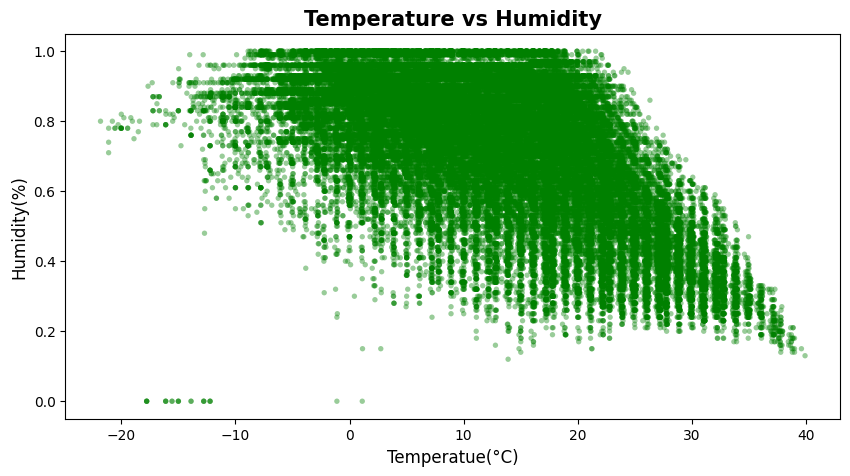

In [14]:
plt.figure(figsize=(10,5))
plt.scatter(df['Temperature (C)'], df['Humidity'],
            alpha=0.4, color='green', edgecolors='none', s=15)

plt.title('Temperature vs Humidity',fontsize=15,fontweight='bold')
plt.xlabel('Temperatue(°C)',fontsize=12)
plt.ylabel('Humidity(%)',fontsize=12)
plt.savefig('scatter_plot.png', dpi=200)

Insight: There is a negative correlation between Temperature
and Humidity. As temperature increases, humidity tends to
decrease, shown by the downward trend in the scatter plot.

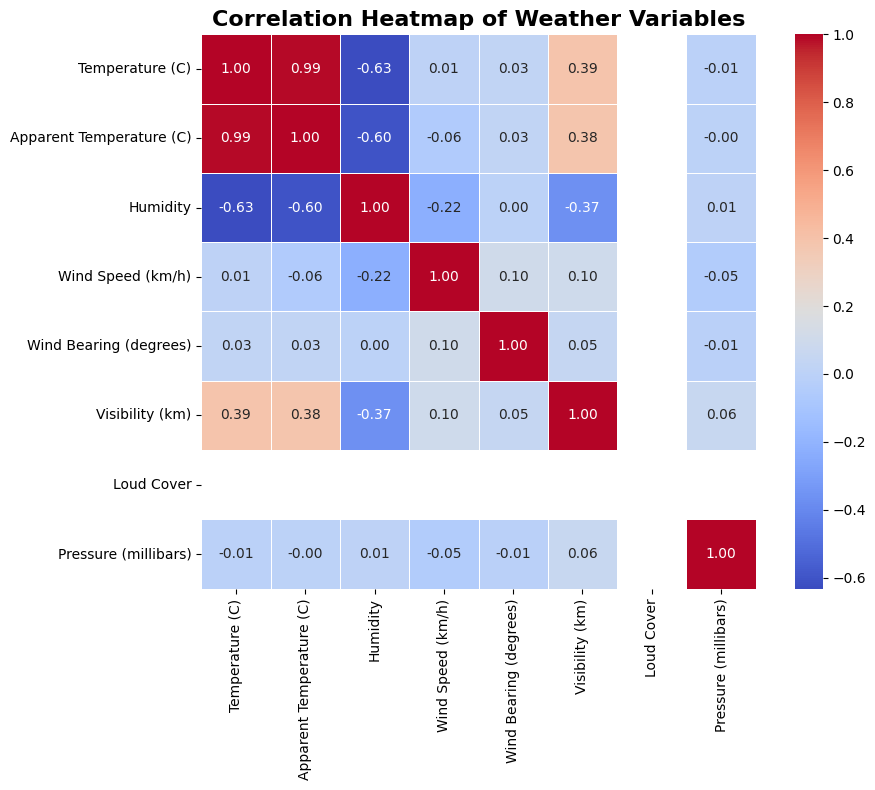

In [15]:
plt.figure(figsize=(10, 8))

# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=np.number)
correlation = numeric_df.corr()

sns.heatmap(correlation,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            square=True,
            linewidths=0.5)

plt.title('Correlation Heatmap of Weather Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150)
plt.show()

Insight: Temperature and Apparent Temperature show a very
strong positive correlation (close to 1.0), meaning they
move almost identically. Humidity shows a moderate negative
correlation with Temperature.

## Summary

This analysis explored a weather dataset using Pandas for
data handling and Matplotlib/Seaborn for visualization.

- The dataset contains weather records with attributes
  like Temperature, Humidity, Wind Speed, and Pressure.
- The average temperature and humidity were calculated
  to understand general weather trends.
- The bar chart revealed that clear weather conditions
  correspond to higher temperatures.
- The scatter plot showed an inverse relationship between
  temperature and humidity.
- The heatmap confirmed strong correlations between related
  variables, particularly Temperature and Apparent Temperature.

Overall, the analysis highlights clear weather patterns and
relationships between key meteorological variables.